In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image
from torchvision import transforms, models

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [3]:
PROJECT_DIR = Path("/content/drive/MyDrive/Knee_OA_Project")

CKPT_PATH = PROJECT_DIR / "experiments" / "resnet50_fullimg256_wce_v1" / "best_model.pt"

DATA_DIR = Path("/content/kneeoa_data")

print(CKPT_PATH)

/content/drive/MyDrive/Knee_OA_Project/experiments/resnet50_fullimg256_wce_v1/best_model.pt


In [5]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [6]:
from pathlib import Path

EXP_DIR = Path("/content/drive/MyDrive/Knee_OA_Project/experiments")

print("EXP_DIR exists:", EXP_DIR.exists())
print("\nExperiment folders:")
for p in sorted(EXP_DIR.iterdir()):
    print("-", p.name)

EXP_DIR exists: True

Experiment folders:
- convnext_tiny_fullimg320_wce_v1
- convnext_tiny_roi320_corn_v1
- densenet121_fullimg256_wce_v1
- resnet50_ensemble_eval
- resnet50_fullimg256_wce_v1
- resnet50_fullimg256_wce_v1_tta
- resnet50_fullimg256_wce_v2
- weighted_3model_ensemble


In [7]:
from pathlib import Path

EXP_DIR = Path("/content/drive/MyDrive/Knee_OA_Project/experiments")

candidate_ckpts = list(EXP_DIR.rglob("best_model.pt"))

print("Found checkpoints:")
for p in candidate_ckpts:
    print("-", p)

# Pick the one for the first improved ResNet run
CKPT_PATH = None
for p in candidate_ckpts:
    if "resnet50" in p.as_posix() and "v1" in p.as_posix():
        CKPT_PATH = p
        break

print("\nSelected CKPT_PATH:", CKPT_PATH)

Found checkpoints:
- /content/drive/MyDrive/Knee_OA_Project/experiments/convnext_tiny_roi320_corn_v1/best_model.pt
- /content/drive/MyDrive/Knee_OA_Project/experiments/convnext_tiny_fullimg320_wce_v1/best_model.pt
- /content/drive/MyDrive/Knee_OA_Project/experiments/resnet50_fullimg256_wce_v1/best_model.pt
- /content/drive/MyDrive/Knee_OA_Project/experiments/resnet50_fullimg256_wce_v2/best_model.pt
- /content/drive/MyDrive/Knee_OA_Project/experiments/densenet121_fullimg256_wce_v1/best_model.pt

Selected CKPT_PATH: /content/drive/MyDrive/Knee_OA_Project/experiments/resnet50_fullimg256_wce_v1/best_model.pt


In [8]:
for p in candidate_ckpts:
    print(p.as_posix())

/content/drive/MyDrive/Knee_OA_Project/experiments/convnext_tiny_roi320_corn_v1/best_model.pt
/content/drive/MyDrive/Knee_OA_Project/experiments/convnext_tiny_fullimg320_wce_v1/best_model.pt
/content/drive/MyDrive/Knee_OA_Project/experiments/resnet50_fullimg256_wce_v1/best_model.pt
/content/drive/MyDrive/Knee_OA_Project/experiments/resnet50_fullimg256_wce_v2/best_model.pt
/content/drive/MyDrive/Knee_OA_Project/experiments/densenet121_fullimg256_wce_v1/best_model.pt


In [9]:
CKPT_PATH = Path("/content/drive/MyDrive/Knee_OA_Project/experiments/ACTUAL_FOLDER_NAME/best_model.pt")
print(CKPT_PATH.exists(), CKPT_PATH)

False /content/drive/MyDrive/Knee_OA_Project/experiments/ACTUAL_FOLDER_NAME/best_model.pt


In [10]:
from pathlib import Path

EXP_DIR = Path("/content/drive/MyDrive/Knee_OA_Project/experiments")

print("EXP_DIR exists:", EXP_DIR.exists())
for p in sorted(EXP_DIR.iterdir()):
    print(p.name)

EXP_DIR exists: True
convnext_tiny_fullimg320_wce_v1
convnext_tiny_roi320_corn_v1
densenet121_fullimg256_wce_v1
resnet50_ensemble_eval
resnet50_fullimg256_wce_v1
resnet50_fullimg256_wce_v1_tta
resnet50_fullimg256_wce_v2
weighted_3model_ensemble


In [11]:
for p in EXP_DIR.rglob("best_model.pt"):
    print(p)

/content/drive/MyDrive/Knee_OA_Project/experiments/convnext_tiny_roi320_corn_v1/best_model.pt
/content/drive/MyDrive/Knee_OA_Project/experiments/convnext_tiny_fullimg320_wce_v1/best_model.pt
/content/drive/MyDrive/Knee_OA_Project/experiments/resnet50_fullimg256_wce_v1/best_model.pt
/content/drive/MyDrive/Knee_OA_Project/experiments/resnet50_fullimg256_wce_v2/best_model.pt
/content/drive/MyDrive/Knee_OA_Project/experiments/densenet121_fullimg256_wce_v1/best_model.pt


In [12]:
from pathlib import Path

CKPT_PATH = Path("/content/drive/MyDrive/Knee_OA_Project/experiments/resnet50_fullimg256_wce_v1/best_model.pt")
print(CKPT_PATH.exists(), CKPT_PATH)

True /content/drive/MyDrive/Knee_OA_Project/experiments/resnet50_fullimg256_wce_v1/best_model.pt


In [13]:
import torch
import torch.nn as nn
from torchvision import models

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights=None)
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.fc.in_features, 5)
)

ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])

model = model.to(DEVICE)
model.eval()

print("Loaded from:", CKPT_PATH)
print("Epoch:", ckpt.get("epoch", "N/A"))

Loaded from: /content/drive/MyDrive/Knee_OA_Project/experiments/resnet50_fullimg256_wce_v1/best_model.pt
Epoch: 7


In [15]:
PROJECT_DIR = Path("/content/drive/MyDrive/Knee_OA_Project")
EXP_DIR = PROJECT_DIR / "experiments"
ZIP_PATH = PROJECT_DIR / "archive (10).zip"

print("PROJECT_DIR exists:", PROJECT_DIR.exists())
print("EXP_DIR exists:", EXP_DIR.exists())
print("ZIP exists:", ZIP_PATH.exists())
print("ZIP path:", ZIP_PATH)

PROJECT_DIR exists: True
EXP_DIR exists: True
ZIP exists: True
ZIP path: /content/drive/MyDrive/Knee_OA_Project/archive (10).zip


In [16]:
print("Experiment folders:")
for p in sorted(EXP_DIR.iterdir()):
    print("-", p.name)

Experiment folders:
- convnext_tiny_fullimg320_wce_v1
- convnext_tiny_roi320_corn_v1
- densenet121_fullimg256_wce_v1
- resnet50_ensemble_eval
- resnet50_fullimg256_wce_v1
- resnet50_fullimg256_wce_v1_tta
- resnet50_fullimg256_wce_v2
- weighted_3model_ensemble


In [17]:
candidate_ckpts = list(EXP_DIR.rglob("best_model.pt"))

print("Found checkpoints:")
for p in candidate_ckpts:
    print("-", p)

Found checkpoints:
- /content/drive/MyDrive/Knee_OA_Project/experiments/convnext_tiny_roi320_corn_v1/best_model.pt
- /content/drive/MyDrive/Knee_OA_Project/experiments/convnext_tiny_fullimg320_wce_v1/best_model.pt
- /content/drive/MyDrive/Knee_OA_Project/experiments/resnet50_fullimg256_wce_v1/best_model.pt
- /content/drive/MyDrive/Knee_OA_Project/experiments/resnet50_fullimg256_wce_v2/best_model.pt
- /content/drive/MyDrive/Knee_OA_Project/experiments/densenet121_fullimg256_wce_v1/best_model.pt


In [18]:
CKPT_PATH = None
for p in candidate_ckpts:
    if "resnet50_fullimg256_wce_v1" in p.as_posix():
        CKPT_PATH = p
        break

print("Selected CKPT_PATH:", CKPT_PATH)
print("Exists:", CKPT_PATH.exists() if CKPT_PATH is not None else None)

Selected CKPT_PATH: /content/drive/MyDrive/Knee_OA_Project/experiments/resnet50_fullimg256_wce_v1/best_model.pt
Exists: True


In [20]:
import zipfile
BASE_EXTRACT_DIR = Path("/content/kneeoa_data")

if not BASE_EXTRACT_DIR.exists():
    BASE_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(BASE_EXTRACT_DIR)
    print("Dataset extracted.")
else:
    print("Dataset folder already exists.")

Dataset folder already exists.


In [30]:
from pathlib import Path
import shutil
import zipfile

ZIP_PATH = Path("/content/drive/MyDrive/Knee_OA_Project/archive (10).zip")
DATA_DIR = Path("/content/kneeoa_data")

print("ZIP exists:", ZIP_PATH.exists())

if DATA_DIR.exists():
    print("Removing existing DATA_DIR:", DATA_DIR)
    shutil.rmtree(DATA_DIR)

DATA_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    zf.extractall(DATA_DIR)

print("Extraction complete.")
print("Top-level contents:", [p.name for p in DATA_DIR.iterdir()])

ZIP exists: True
Removing existing DATA_DIR: /content/kneeoa_data
Extraction complete.
Top-level contents: ['auto_test', 'train', 'val', 'test']


In [31]:
from pathlib import Path

base_dir = Path("/content/kneeoa_data")

def find_dataset_root(base_dir: Path):
    candidates = [base_dir] + [p for p in base_dir.rglob("*") if p.is_dir()]
    for c in candidates:
        if (c / "train").exists() and (c / "val").exists() and (c / "test").exists():
            return c
    return None

DATA_DIR = find_dataset_root(base_dir)

print("Detected DATA_DIR:", DATA_DIR)
print("Contents:", [p.name for p in DATA_DIR.iterdir()])

Detected DATA_DIR: /content/kneeoa_data
Contents: ['auto_test', 'train', 'val', 'test']


In [32]:
test_dir = DATA_DIR / "test"

print("test_dir exists:", test_dir.exists())
print("Class folders:", [p.name for p in test_dir.iterdir() if p.is_dir()])

for cls_dir in sorted([p for p in test_dir.iterdir() if p.is_dir()]):
    files = list(cls_dir.iterdir())[:3]
    print(f"\n{cls_dir.name} sample files:")
    for f in files:
        print(" -", f.name)

test_dir exists: True
Class folders: ['3', '4', '1', '0', '2']

0 sample files:
 - 9827858L.png
 - 9030418R.png
 - 9594682R.png

1 sample files:
 - 9706172L.png
 - 9784803R.png
 - 9419076L.png

2 sample files:
 - 9357226R.png
 - 9560965R.png
 - 9928592R.png

3 sample files:
 - 9087632R.png
 - 9369649L.png
 - 9853523L.png

4 sample files:
 - 9390064R.png
 - 9282257R.png
 - 9996865L.png


In [22]:
model = models.resnet50(weights=None)
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.fc.in_features, 5)
)

ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])

model = model.to(DEVICE)
model.eval()

print("Loaded from:", CKPT_PATH)
print("Epoch:", ckpt.get("epoch", "N/A"))

Loaded from: /content/drive/MyDrive/Knee_OA_Project/experiments/resnet50_fullimg256_wce_v1/best_model.pt
Epoch: 7


In [23]:
IMG_SIZE = 256

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

In [24]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.fwd_handle = target_layer.register_forward_hook(self.save_activation)
        self.bwd_handle = target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, inp, out):
        self.activations = out

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, x, class_idx):
        output = self.model(x)
        self.model.zero_grad()

        score = output[:, class_idx]
        score.backward()

        gradients = self.gradients[0].detach().cpu().numpy()
        activations = self.activations[0].detach().cpu().numpy()

        weights = gradients.mean(axis=(1, 2))
        cam = np.zeros(activations.shape[1:], dtype=np.float32)

        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = np.maximum(cam, 0)
        if cam.max() > 0:
            cam = cam / cam.max()

        return cam

In [25]:
target_layer = model.layer4[-1]
gradcam = GradCAM(model, target_layer)

print("GradCAM ready.")

GradCAM ready.


In [33]:
valid_exts = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

sample_candidates = [
    p for p in (DATA_DIR / "test").rglob("*")
    if p.is_file() and p.suffix.lower() in valid_exts
]

print("Total test images found:", len(sample_candidates))

if len(sample_candidates) == 0:
    raise ValueError("Still no test images found after re-extraction.")

sample_img_path = sample_candidates[0]
print("Sample image:", sample_img_path)

Total test images found: 1656
Sample image: /content/kneeoa_data/test/3/9087632R.png


In [35]:
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [36]:
img = Image.open(sample_img_path)
img = ImageOps.exif_transpose(img)

x = transform(img).unsqueeze(0).to(DEVICE)

print("Input tensor shape:", x.shape)

Input tensor shape: torch.Size([1, 3, 256, 256])


In [37]:
logits = model(x)
pred = torch.argmax(logits, dim=1).item()

cam = gradcam.generate(x, pred)

print("Predicted KL grade:", pred)
print("CAM shape:", cam.shape)

Predicted KL grade: 3
CAM shape: (8, 8)


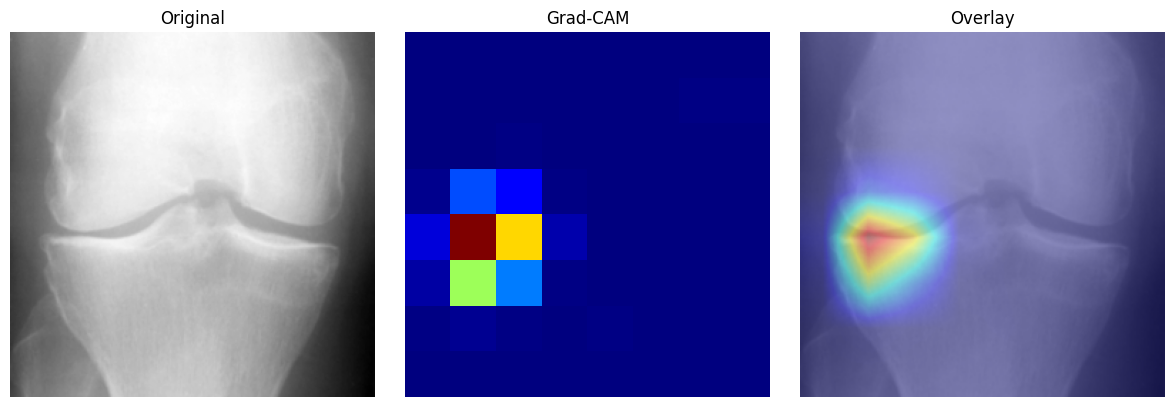

In [38]:
img_gray = img.convert("L").resize((IMG_SIZE, IMG_SIZE))
img_np = np.array(img_gray)

heatmap = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

img_rgb = np.stack([img_np, img_np, img_np], axis=-1)
overlay = (0.6 * img_rgb + 0.4 * heatmap).astype(np.uint8)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_np, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam, cmap="jet")
plt.title("Grad-CAM")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

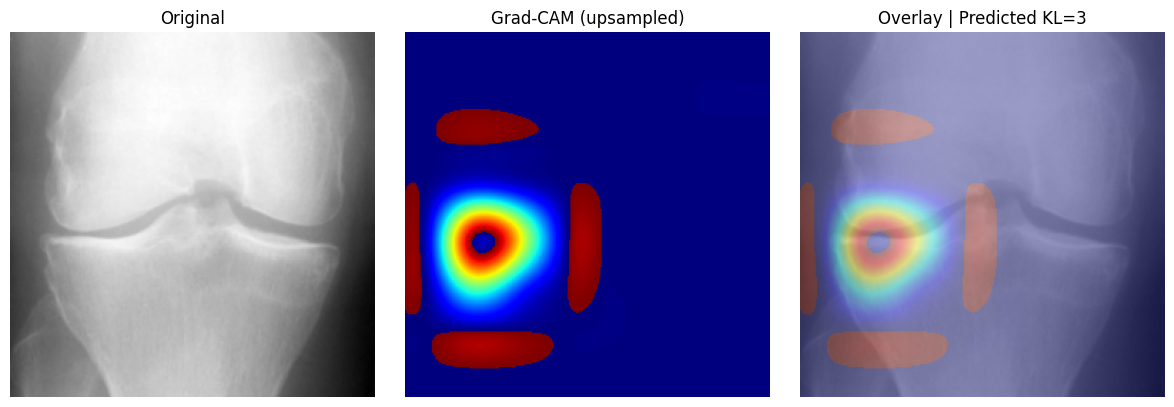

In [39]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMG_SIZE = 256

img_gray = img.convert("L").resize((IMG_SIZE, IMG_SIZE))
img_np = np.array(img_gray)

heatmap = cv2.resize(cam, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_CUBIC)
heatmap = np.uint8(255 * heatmap)
heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

img_rgb = np.stack([img_np, img_np, img_np], axis=-1)
overlay = (0.65 * img_rgb + 0.35 * heatmap_color).astype(np.uint8)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_np, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap, cmap="jet")
plt.title("Grad-CAM (upsampled)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title(f"Overlay | Predicted KL={pred}")
plt.axis("off")

plt.tight_layout()
plt.show()

In [40]:
import pandas as pd

CLASS_NAMES = ["0", "1", "2", "3", "4"]
rows = []

for split in ["train", "val", "test"]:
    split_dir = DATA_DIR / split
    for cls in CLASS_NAMES:
        cls_dir = split_dir / cls
        if not cls_dir.exists():
            continue
        for p in cls_dir.rglob("*"):
            if p.is_file() and p.suffix.lower() in {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}:
                rows.append({
                    "path": str(p),
                    "label": int(cls),
                    "split": split
                })

df = pd.DataFrame(rows)
test_df = df[df["split"] == "test"].reset_index(drop=True)

print(test_df.shape)
test_df.head()

(1656, 3)


,path,label,split
0,/content/kneeoa_data/test/0/9827858L.png,0,test
1,/content/kneeoa_data/test/0/9030418R.png,0,test
2,/content/kneeoa_data/test/0/9594682R.png,0,test
3,/content/kneeoa_data/test/0/9733523L.png,0,test
4,/content/kneeoa_data/test/0/9789177L.png,0,test


In [41]:
@torch.no_grad()
def predict_one_image(path):
    img = Image.open(path)
    img = ImageOps.exif_transpose(img)
    x = transform(img).unsqueeze(0).to(DEVICE)

    logits = model(x)
    pred = torch.argmax(logits, dim=1).item()

    return pred

test_df["y_pred"] = test_df["path"].apply(predict_one_image)
test_df["correct"] = (test_df["label"] == test_df["y_pred"]).astype(int)

print(test_df["correct"].value_counts())
test_df.head()

correct
1    1102
0     554
Name: count, dtype: int64


,path,label,split,y_pred,correct
0,/content/kneeoa_data/test/0/9827858L.png,0,test,0,1
1,/content/kneeoa_data/test/0/9030418R.png,0,test,0,1
2,/content/kneeoa_data/test/0/9594682R.png,0,test,0,1
3,/content/kneeoa_data/test/0/9733523L.png,0,test,1,0
4,/content/kneeoa_data/test/0/9789177L.png,0,test,0,1


In [42]:
correct_df = test_df[test_df["correct"] == 1].copy()
wrong_df   = test_df[test_df["correct"] == 0].copy()

correct_samples = correct_df.groupby("label", group_keys=False).head(1)
wrong_samples   = wrong_df.groupby("label", group_keys=False).head(1)

display_df = pd.concat([correct_samples, wrong_samples], axis=0).reset_index(drop=True)
display_df[["path", "label", "y_pred", "correct"]]

,path,label,y_pred,correct
0,/content/kneeoa_data/test/0/9827858L.png,0,0,1
1,/content/kneeoa_data/test/1/9706172L.png,1,1,1
2,/content/kneeoa_data/test/2/9560965R.png,2,2,1
3,/content/kneeoa_data/test/3/9087632R.png,3,3,1
4,/content/kneeoa_data/test/4/9390064R.png,4,4,1
5,/content/kneeoa_data/test/0/9733523L.png,0,1,0
6,/content/kneeoa_data/test/1/9419076L.png,1,0,0
7,/content/kneeoa_data/test/2/9357226R.png,2,1,0
8,/content/kneeoa_data/test/3/9853523L.png,3,2,0
9,/content/kneeoa_data/test/4/9964731L.png,4,3,0


In [43]:
def make_gradcam_figure(image_path, true_label):
    img = Image.open(image_path)
    img = ImageOps.exif_transpose(img)
    x = transform(img).unsqueeze(0).to(DEVICE)

    logits = model(x)
    pred = torch.argmax(logits, dim=1).item()
    cam = gradcam.generate(x, pred)

    img_gray = img.convert("L").resize((IMG_SIZE, IMG_SIZE))
    img_np = np.array(img_gray)

    heatmap = cv2.resize(cam, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_CUBIC)
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    img_rgb = np.stack([img_np, img_np, img_np], axis=-1)
    overlay = (0.65 * img_rgb + 0.35 * heatmap_color).astype(np.uint8)

    return img_np, heatmap, overlay, pred

n = len(display_df)
fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))

if n == 1:
    axes = np.expand_dims(axes, axis=0)

for i, row in display_df.iterrows():
    img_np, heatmap, overlay, pred = make_gradcam_figure(row["path"], row["label"])

    axes[i, 0].imshow(img_np, cmap="gray")
    axes[i, 0].set_title(f"Original | True={row['label']}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(heatmap, cmap="jet")
    axes[i, 1].set_title("Grad-CAM")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(overlay)
    axes[i, 2].set_title(f"Overlay | Pred={pred} | Correct={row['correct']}")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [44]:
OUTPUT_DIR = PROJECT_DIR / "gradcam_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SAVE_PATH = OUTPUT_DIR / "gradcam_multiple_examples.png"
fig.savefig(SAVE_PATH, dpi=200, bbox_inches="tight")

print("Saved:", SAVE_PATH)

Saved: /content/drive/MyDrive/Knee_OA_Project/gradcam_outputs/gradcam_multiple_examples.png


In [45]:
target_layer_l3 = model.layer3[-1]
gradcam_l3 = GradCAM(model, target_layer_l3)

print("Layer3 GradCAM ready.")

Layer3 GradCAM ready.


In [46]:
cam_l3 = gradcam_l3.generate(x, pred)

print("Predicted KL grade:", pred)
print("Layer3 CAM shape:", cam_l3.shape)

Predicted KL grade: 3
Layer3 CAM shape: (16, 16)


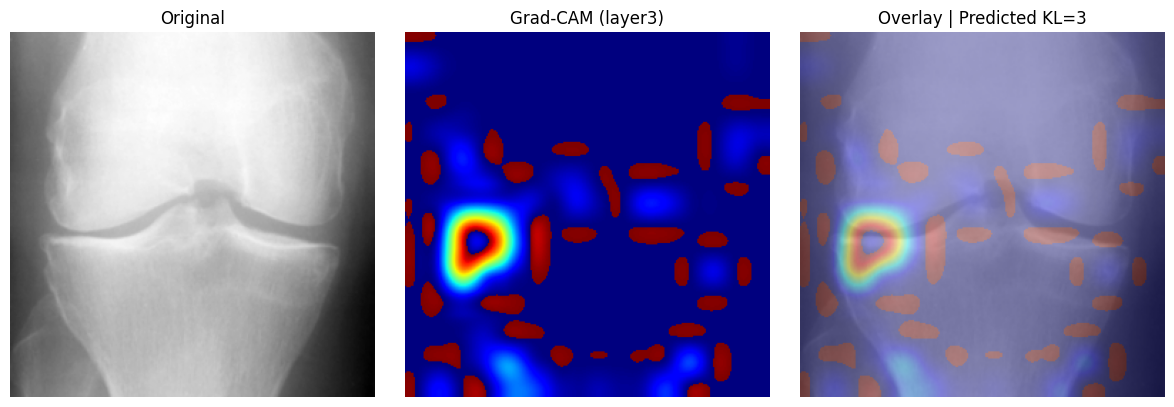

In [47]:
IMG_SIZE = 256

img_gray = img.convert("L").resize((IMG_SIZE, IMG_SIZE))
img_np = np.array(img_gray)

heatmap_l3 = cv2.resize(cam_l3, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_CUBIC)
heatmap_l3 = np.uint8(255 * heatmap_l3)
heatmap_color_l3 = cv2.applyColorMap(heatmap_l3, cv2.COLORMAP_JET)
heatmap_color_l3 = cv2.cvtColor(heatmap_color_l3, cv2.COLOR_BGR2RGB)

img_rgb = np.stack([img_np, img_np, img_np], axis=-1)
overlay_l3 = (0.65 * img_rgb + 0.35 * heatmap_color_l3).astype(np.uint8)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_np, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap_l3, cmap="jet")
plt.title("Grad-CAM (layer3)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay_l3)
plt.title(f"Overlay | Predicted KL={pred}")
plt.axis("off")

plt.tight_layout()
plt.show()

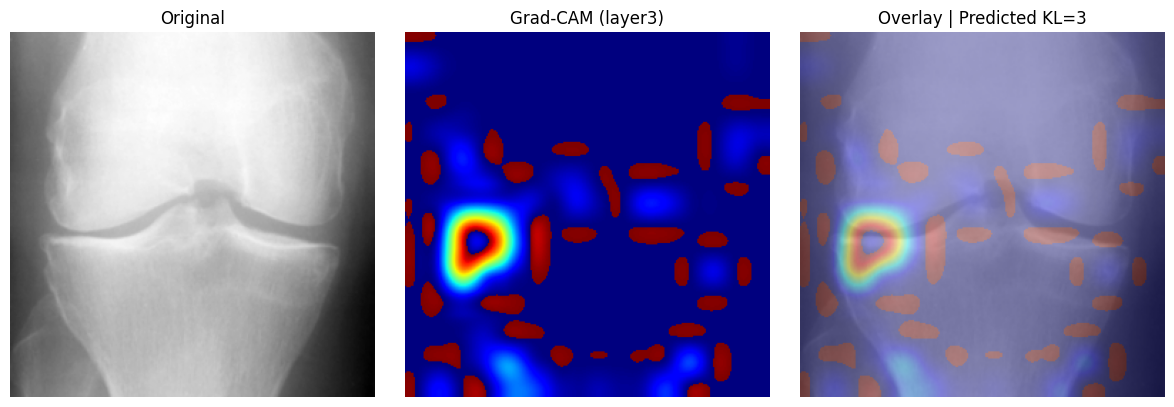

Saved: /content/drive/MyDrive/Knee_OA_Project/gradcam_outputs/gradcam_layer3_example.png


In [48]:
OUTPUT_DIR = PROJECT_DIR / "gradcam_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SAVE_PATH_L3 = OUTPUT_DIR / "gradcam_layer3_example.png"

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_np, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap_l3, cmap="jet")
plt.title("Grad-CAM (layer3)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay_l3)
plt.title(f"Overlay | Predicted KL={pred}")
plt.axis("off")

plt.tight_layout()
plt.savefig(SAVE_PATH_L3, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", SAVE_PATH_L3)